# `DomainCubic` — Tutorial

`DomainCubic` is the central class for defining the spatial (and optional temporal) domain in a PINN problem. It supports:

- **Plain** domains — a simple axis-aligned box defined by `(min, max)` per dimension.
- **Partitioned** domains — the box is split into a structured grid of sub-cells by providing breakpoint arrays.
- **Time** — an optional time axis, either continuous (`[t0, t1]`) or partitioned (`[t0, t1, …, tn]`).

Once constructed, `DomainCubic` lets you:
1. Query geometric properties (bounds, volume, sub-domain info).
2. Register named interior and boundary regions.
3. Sample points from any region for training.
4. Visualise the domain and sampled points.


## Imports

In [1]:
%matplotlib widget
import pinns
import numpy as np

---
## 1. Construction

`DomainCubic` is created by passing a list with one entry per spatial dimension.

| Argument style | Meaning |
|---|---|
| `(min, max)` | Plain continuous box along that axis |
| `[b0, b1, …, bn]` (≥3 values) | Partitioned axis — breakpoints define `n-1` sub-cells |

All dimensions **must** use the same style (either all plain tuples or all breakpoint lists).

```python
# Plain 2-D box  [0,1] × [0,1]
DomainCubic([(0, 1), (0, 1)])

# Partitioned 2-D: 2×2 grid of sub-cells
DomainCubic([[0, 0.5, 1], [0, 0.5, 1]])

# Add a continuous time axis  t ∈ [0, 10]
DomainCubic([(0, 1), (0, 1)], time=[0, 10])

# Add a partitioned time axis: two time slabs [0,5] and [5,10]
DomainCubic([(0, 1), (0, 1)], time=[0, 5, 10])
```

In [2]:
from pinns.domain import DomainCubic

# ── Plain box ────────────────────────────────────────────────────────────────
plain_1d = DomainCubic([(0, 1)])
plain_2d = DomainCubic([(0, 1), (-1, 2)])
plain_3d = DomainCubic([(0, 1), (0, 1), (0, 1)])

# ── Partitioned box  (breakpoint arrays, one per dimension) ──────────────────
part_2d = DomainCubic([[0, 0.5, 1],       # x: 2 cells
                        [0, 0.5, 1]])      # y: 2 cells  → 4 sub-cells total

part_3d = DomainCubic([[0, 0.5, 1],
                        [0, 0.5, 1],
                        [0, 0.5, 1]])      # 2×2×2 = 8 sub-cells

# ── With time ─────────────────────────────────────────────────────────────────
with_time      = DomainCubic([(0, 1), (0, 1)], time=[0, 1])        # continuous
with_time_part = DomainCubic([(0, 1), (0, 1)], time=[0, 0.5, 1])   # 2 time slabs

print("plain_2d       :", plain_2d)
print("part_2d        :", part_2d)
print("with_time      :", with_time)
print("with_time_part :", with_time_part)

plain_2d       : DomainCubic(space=[(0.0, 1.0), (-1.0, 2.0)], n_conditions=0)
part_2d        : DomainCubic(space=[(0.0, 1.0), (0.0, 1.0)], n_subdomains_per_dim=[2, 2], total_subdomains=4, n_conditions=0)
with_time      : DomainCubic(space=[(0.0, 1.0), (0.0, 1.0)], time=[0.0, 1.0], n_conditions=0)
with_time_part : DomainCubic(space=[(0.0, 1.0), (0.0, 1.0)], time=[0.0, 1.0], n_time_subdomains=2, n_conditions=0)


---
## 2. Geometric properties

| Property | Description |
|---|---|
| `bounds` | `(xmin, xmax)` arrays |
| `extents` | `xmax - xmin` per dimension |
| `volume` | product of all extents |
| `has_time` | `True` if a time axis was given |
| `is_time_partitioned` | `True` if time has multiple slabs |
| `n_dims` | total dimensionality (space + time) |
| `_spatial_dims` | number of spatial dimensions only |

In [3]:
d = DomainCubic([(0, 2), (0, 3)], time=[0, 1])

lo, hi = d.bounds
print("xmin          :", lo)
print("xmax          :", hi)
print("extents       :", d.extents)
print("volume        :", d.volume)
print("has_time      :", d.has_time)
print("partitioned t :", d.is_time_partitioned)
print("n_dims        :", d.n_dims,        "  (space + time)")
print("spatial_dims  :", d._spatial_dims, "  (space only)")

xmin          : [0. 0. 0.]
xmax          : [2. 3. 1.]
extents       : [2. 3. 1.]
volume        : 6.0
has_time      : True
partitioned t : False
n_dims        : 3   (space + time)
spatial_dims  : 2   (space only)


---
## 3. Partition utilities

When the domain is **partitioned**, these helpers describe the sub-cell grid.

| Method / Property | Returns | Description |
|---|---|---|
| `n_subdomains` | `int` | total number of sub-cells |
| `n_subdomains_per_dim` | `list[int]` | sub-cell count per spatial dim |
| `subdomains` | `list[SubdomainInfo]` | list of sub-cell objects (each has `.xmin`/`.xmax`) |
| `get_subdomain_centers()` | `(N, d)` array | centroid of every sub-cell |
| `get_subdomain_bounds()` | two `(N, d)` arrays | lower & upper corners of every sub-cell |
| `get_multi_index(flat_i)` | tuple of ints | converts a flat sub-cell index to per-dim indices |
| `get_internal_boundary_positions(dim)` | 1-D array | interior breakpoint positions along dimension `dim` |
| `len(domain)` | `int` | same as `n_subdomains` |
| `to_numpy()` | `float32 (N, d)` | sub-cell centres as a NumPy array |
| `contains(x)` | bool / bool array | whether a point (or batch) lies inside the domain |

In [4]:
dp = DomainCubic([[0, 0.5, 1], [0, 0.5, 1]])   # 2×2 = 4 sub-cells

print("n_subdomains         :", dp.n_subdomains)
print("n_subdomains_per_dim :", dp.n_subdomains_per_dim)
print()

centers = dp.get_subdomain_centers()
print("Sub-cell centres (flat order):\n", centers)
print()

lo, hi = dp.get_subdomain_bounds()
print("Lower corners:\n", lo)
print("Upper corners:\n", hi)
print()

# Flat index → per-dimension multi-index
for i in range(dp.n_subdomains):
    print(f"  flat {i} → multi-index {dp.get_multi_index(i)}")
print()

# Interior breakpoints along dim 0
print("Internal breakpoints dim-0:", dp.get_internal_boundary_positions(0))

# len / to_numpy / contains
print("len(dp) :", len(dp))
print("contains([0.25, 0.25]):", dp.contains(np.array([0.25, 0.25])))

n_subdomains         : 4
n_subdomains_per_dim : [2, 2]

Sub-cell centres (flat order):
 [[0.25 0.25]
 [0.25 0.75]
 [0.75 0.25]
 [0.75 0.75]]

Lower corners:
 [[0.  0. ]
 [0.  0.5]
 [0.5 0. ]
 [0.5 0.5]]
Upper corners:
 [[0.5 0.5]
 [0.5 1. ]
 [1.  0.5]
 [1.  1. ]]

  flat 0 → multi-index (0, 0)
  flat 1 → multi-index (0, 1)
  flat 2 → multi-index (1, 0)
  flat 3 → multi-index (1, 1)

Internal breakpoints dim-0: [0.5]
len(dp) : 4
contains([0.25, 0.25]): True


---
## 4. Registering named regions

Named regions give you fine-grained control when sampling. There are two kinds:

### 4.1 `add_inner(domain_spec, name, time=None)`

Registers a rectangular **interior** sub-region.

- `domain_spec` — a list of `(lo, hi)` tuples, one per spatial dimension.
- `time` — optional time restriction:
  - `None` → full time range (default).
  - `int` → partition index (only valid when time is partitioned).
  - `(t_lo, t_hi)` tuple → explicit time window.

### 4.2 `add_boundary(domain_spec, name, time=None)`

Registers a rectangular sub-region on a **boundary face**.

- `domain_spec` — same as above except **exactly one** element must be the string `'min'` or `'max'` to select the face. All other elements are `(lo, hi)` ranges restricting that face.
- `time` — same options as `add_inner`.

> **Tip:** Registered regions appear automatically in `plot()` and can be passed by name (or as a list of names) to the `region=` argument of `sample_interior` / `sample_boundary`.

In [5]:
dr = DomainCubic([[0, 0.5, 1], [0, 0.5, 1]], time=[0, 0.5, 1])

# ── Interior regions ──────────────────────────────────────────────────────────

# Region covering the whole domain (both time slabs)
dr.add_inner([(0.0, 1.0), (0.0, 1.0)], name='full_interior')

# Small central region, only during the first time slab (index 0 → [0, 0.5])
dr.add_inner([(0.3, 0.7), (0.3, 0.7)], name='centre_t0', time=0)

# Left half of the domain, explicit time window [0.5, 1]
dr.add_inner([(0.0, 0.5), (0.0, 1.0)], name='left_late', time=(0.5, 1.0))

# ── Boundary regions ──────────────────────────────────────────────────────────

# The entire x=0 face (all y, all time)
dr.add_boundary(['min', (0, 1)], name='x_left')

# The x=1 face but only y ∈ [0.2, 0.8], during time slab 1 ([0.5, 1])
dr.add_boundary(['max', (0.2, 0.8)], name='x_right_mid_late', time=1)

# The y=0 face (all x)
dr.add_boundary([(0, 1), 'min'], name='y_bottom')

print("Registered inner regions   :", list(dr._inner_regions.keys()))
print("Registered boundary regions:", list(dr._boundary_regions.keys()))

Registered inner regions   : ['full_interior', 'centre_t0', 'left_late']
Registered boundary regions: ['x_left', 'x_right_mid_late', 'y_bottom']


---
## 5. Sampling

### `sample_interior(n_points, region=None, size='equal', rng=None, method=None, transform=None, params=None, mode='uniform')`

Returns an `(n_points, n_dims)` array of collocation points inside the domain.

**`region` values:**

| Value | Behaviour |
|---|---|
| `None` or `'all'` | Sample uniformly from the entire domain |
| `'subdomains'` | Distribute `n_points` equally across all sub-cells (requires partition) |
| `'name'` | Sample from the named inner region |
| `(i, j)` or `(i, j, t)` | Sample from a specific sub-cell by multi-index (and optional time partition index) |
| `['a', 'b', …]` | Sample from multiple named regions; use `size=` to control distribution |

**`size` values (when `region` is a list):**

| Value | Behaviour |
|---|---|
| `'equal'` | Split `n_points` equally among regions |
| `'size'` | Weight by region volume |
| `[w1, w2, …]` | Explicit weights (must sum ≤ 1) |

---

### `sample_boundary(n_points, region=None, size='equal', rng=None, method=None, transform=None, params=None)`

Same interface, but returns points **on the boundary faces**.  
`region=None` / `'all'` samples all faces proportionally to their area.  
Use a named boundary region (or a list of them) to restrict to specific faces.

In [6]:
rng = np.random.default_rng(42)

ds = DomainCubic([[0, 0.5, 1], [0, 0.5, 1]], time=[0, 0.5, 1])
ds.add_inner([(0.3, 0.7), (0.3, 0.7)], name='centre')
ds.add_boundary(['min', (0, 1)], name='x_left')
ds.add_boundary(['max', (0, 1)], name='x_right')

# ── sample_interior region variants ──────────────────────────────────────────

# 1. Whole domain
pts_all    = ds.sample_interior(200, region='all', rng=rng)

# 2. Equal split across all 4 sub-cells
pts_sub    = ds.sample_interior(200, region='subdomains', rng=rng)

# 3. Specific sub-cell by multi-index (cell [1,0]) + time slab 1
pts_cell   = ds.sample_interior(200, region=(1, 0, 1), rng=rng)

# 4. Named interior region
pts_centre = ds.sample_interior(200, region='centre', rng=rng)

# 5. Multiple regions — equal split
pts_multi  = ds.sample_interior(200, region=['centre', 'all'], size='equal', rng=rng)

# 6. Multiple regions — explicit weights
pts_wtd    = ds.sample_interior(200, region=['centre', 'all'], size=[0.8, 0.2], rng=rng)

# ── sample_boundary region variants ──────────────────────────────────────────

# All faces
pts_bnd_all   = ds.sample_boundary(200, region='all', rng=rng)

# Single named face
pts_left      = ds.sample_boundary(200, region='x_left', rng=rng)

# Multiple named faces — 30 % left, 70 % right
pts_lr        = ds.sample_boundary(200, region=['x_left', 'x_right'], size=[0.3, 0.7], rng=rng)

print(f"{'region':30s}  shape           x range")
print("-" * 65)
rows = [
    ("all interior",            pts_all),
    ("subdomains",              pts_sub),
    ("cell (1,0) t-slab 1",    pts_cell),
    ("named centre",            pts_centre),
    ("multi equal",             pts_multi),
    ("multi weighted",          pts_wtd),
    ("boundary all",            pts_bnd_all),
    ("boundary x_left",         pts_left),
    ("boundary left+right wtd", pts_lr),
]
for label, arr in rows:
    xmin, xmax = arr[:, 0].min(), arr[:, 0].max()
    print(f"  {label:28s}  {str(arr.shape):16s} x∈[{xmin:.2f},{xmax:.2f}]")

region                          shape           x range
-----------------------------------------------------------------
  all interior                  (200, 3)         x∈[0.01,0.98]
  subdomains                    (200, 3)         x∈[0.00,1.00]
  cell (1,0) t-slab 1           (200, 3)         x∈[0.50,1.00]
  named centre                  (200, 3)         x∈[0.30,0.70]
  multi equal                   (200, 3)         x∈[0.00,1.00]
  multi weighted                (200, 3)         x∈[0.00,0.99]
  boundary all                  (200, 3)         x∈[0.00,1.00]
  boundary x_left               (200, 3)         x∈[0.00,0.00]
  boundary left+right wtd       (200, 3)         x∈[0.00,1.00]


---
## 6. Visualisation

### `plot(show_overlaps=False, region='all', boundary=None, show_bcs=True, n_samples=0, points=None, figsize=None, backend='auto')`

Renders the domain geometry interactively.

| Argument | Default | Description |
|---|---|---|
| `region` | `'all'` | Which **interior** regions to highlight. `'all'` shows partition grid + every named inner region; `'subdomains'` shows only the grid; a name or list of names highlights those regions only |
| `boundary` | `None` | Which **boundary** regions to highlight (`'all'`, a name, or a list). `None` skips boundary highlights |
| `show_bcs` | `True` | Overlay any boundary conditions attached by `problem.py` |
| `n_samples` | `0` | If > 0, draw `n_samples` random collocation points on top |
| `points` | `None` | Pre-computed point array `(N, d)` to scatter over the domain |
| `show_overlaps` | `False` | Shade the overlap areas when named regions intersect |
| `backend` | `'auto'` | `'matplotlib'` for 1-D/2-D, `'pyvista'` for 3-D; `'auto'` picks automatically |

<Axes: xlabel='x', ylabel='y'>

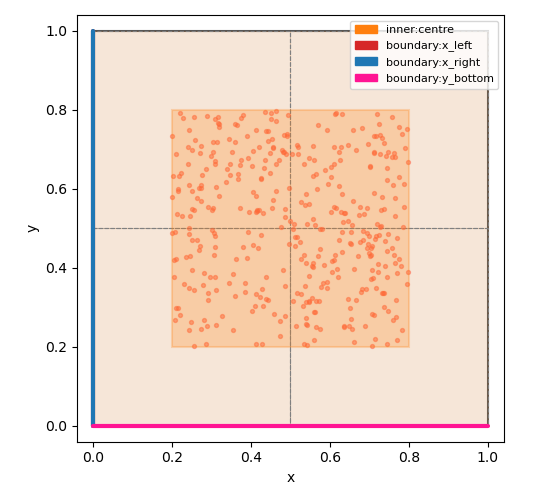

In [7]:
dv = DomainCubic([[0, 0.5, 1], [0, 0.5, 1]], time=[0, 1])
dv.add_inner([(0.2, 0.8), (0.2, 0.8)], name='centre')
dv.add_boundary(['min', (0, 1)], name='x_left')
dv.add_boundary(['max', (0, 1)], name='x_right')
dv.add_boundary([(0, 1), 'min'], name='y_bottom')

pts = dv.sample_interior(400, region='centre', rng=np.random.default_rng(0))

# Show all named interior regions highlighted, highlight all boundary regions,
# and scatter the sampled points

dv.plot(region='all', boundary='all', points=pts, backend='matplotlib')